In [1]:
# ==============================================================================
# PROJETO: Análise Epidemiológica da Dengue em Taubaté/SP
# AUTOR: Portfólio de Análise de Dados
# DESCRIÇÃO: Script completo de ETL (Limpeza/Tratamento) e Geração de Gráficos
# ==============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# 1. CONFIGURAÇÕES DE CAMINHOS E ESTILO VISUAL
# ------------------------------------------------------------------------------
# Ajuste os caminhos conforme a estrutura das suas pastas
PASTA_ENTRADA = r"C:\Users\cdtan\OneDrive\Documentos\PROJETOS\PROJETO_DENGUE\Dados\Brutos"
PASTA_SAIDA = r"C:\Users\cdtan\OneDrive\Documentos\PROJETO_DENGUE_VF\dados"
PASTA_IMAGENS = "imagens"

# Criar pastas de saída caso não existam
os.makedirs(PASTA_SAIDA, exist_ok=True)
os.makedirs(PASTA_IMAGENS, exist_ok=True)

# Configurações do Matplotlib / Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'


In [2]:
# ------------------------------------------------------------------------------
# 2. FUNÇÃO GENÉRICA DE LEITURA E UNPIVOT (MELT) DO TABNET
# ------------------------------------------------------------------------------
def limpar_datasus_generico(caminho_arquivo, var_coluna='Ano', pular_linhas=4):
    """
    Realiza a leitura e transformação (Tidy Data) dos arquivos brutos do TABNET.
    """
    # 1. Leitura do CSV
    df = pd.read_csv(caminho_arquivo, sep=';', encoding='iso-8859-1', skiprows=pular_linhas)
    coluna_cat = df.columns[0]
    
    # 2. Remover nulos na primeira coluna
    df = df.dropna(subset=[coluna_cat])
    
    # 3. Padronizar nome da primeira coluna
    df_clean = df.copy()
    df_clean.rename(columns={coluna_cat: 'Categoria'}, inplace=True)
    
    # 4. Remover coluna de 'Total' agregada
    if 'Total' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Total'])
        
    # 5. Transformação de Matriz (Wide) para Formato Longo (Tidy Data)
    cols_pivot = [c for c in df_clean.columns if c != 'Categoria']
    df_tidy = pd.melt(
        df_clean,
        id_vars=['Categoria'],
        value_vars=cols_pivot,
        var_name=var_coluna,
        value_name='Casos'
    )
    
    # 6. Tratamento de tipos de dados e remoção de caracteres nulos do TABNET ('-', '...')
    df_tidy['Casos'] = df_tidy['Casos'].astype(str).str.replace('-', '0').str.strip()
    df_tidy['Casos'] = pd.to_numeric(df_tidy['Casos'], errors='coerce').fillna(0).astype(int)
    df_tidy['Categoria'] = df_tidy['Categoria'].astype(str).str.strip()
    
    return df_tidy


In [3]:
# ------------------------------------------------------------------------------
# 3. LEITURA E PROCESSAMENTO DAS BASES BRUTAS
# ------------------------------------------------------------------------------
print("⏳ Iniciando processamento dos dados brutos...")

# --- 3.1. Sazonalidade (Ano x Mês) ---
caminho_saz = os.path.join(PASTA_ENTRADA, "sinannet_cnv_denguebsp091745177_170_142_133_ano_mes.csv")
df_sazonalidade = limpar_datasus_generico(caminho_saz, var_coluna='Mes', pular_linhas=4)
df_sazonalidade.rename(columns={'Categoria': 'Ano'}, inplace=True)

# --- 3.2. Faixa Etária (Faixa Etária x Ano) ---
caminho_faixa = os.path.join(PASTA_ENTRADA, "sinannet_cnv_denguebsp092221177_170_142_133_Faixa_Etaria.csv")
df_faixa_etaria = limpar_datasus_generico(caminho_faixa, var_coluna='Ano', pular_linhas=4)
df_faixa_etaria.rename(columns={'Categoria': 'Faixa_Etaria'}, inplace=True)

# --- 3.3. Sexo e Evolução (Pula 5 linhas devido ao cabeçalho adicional do TABNET) ---
caminho_masc = os.path.join(PASTA_ENTRADA, "sinannet_cnv_denguebsp092725177_170_142_133_masculino.csv")
caminho_fem = os.path.join(PASTA_ENTRADA, "sinannet_cnv_denguebsp092807177_170_142_133_feminino.csv")

df_masc = limpar_datasus_generico(caminho_masc, var_coluna='Ano', pular_linhas=5)
df_masc.rename(columns={'Categoria': 'Evolucao'}, inplace=True)
df_masc['Sexo'] = 'Masculino'

df_fem = limpar_datasus_generico(caminho_fem, var_coluna='Ano', pular_linhas=5)
df_fem.rename(columns={'Categoria': 'Evolucao'}, inplace=True)
df_fem['Sexo'] = 'Feminino'

# Unificando as bases masculinas e femininas
df_sexo_evolucao = pd.concat([df_masc, df_fem], ignore_index=True)


⏳ Iniciando processamento dos dados brutos...


In [4]:
# ------------------------------------------------------------------------------
# 4. LIMPEZA DEFINITIVA VIA WHITELIST (ELIMINAÇÃO DE RODAPÉS DO DATASUS)
# ------------------------------------------------------------------------------
print("🧹 Aplicando filtros estritos de remoção de rodapés...")

# 1. Sazonalidade: Manter apenas anos válidos de 4 dígitos (ex: 2015 a 2025)
df_sazonalidade = df_sazonalidade[
    df_sazonalidade['Ano'].astype(str).str.contains(r'^\d{4}$', na=False)
].copy()

# 2. Faixa Etária: Manter apenas idades oficiais do DATASUS
FAIXAS_VALIDAS = [
    'Em branco/IGN', '<1 Ano', '1-4', '5-9', '10-14', '15-19', 
    '20-39', '40-59', '60-64', '65-69', '70-79', '80 e +'
]
df_faixa_etaria = df_faixa_etaria[
    (df_faixa_etaria['Faixa_Etaria'].isin(FAIXAS_VALIDAS)) & 
    (df_faixa_etaria['Ano'].astype(str).str.contains(r'^\d{4}$', na=False))
].copy()

# 3. Sexo e Evolução: Manter apenas desfechos clínicos válidos
EVOLUCOES_VALIDAS = [
    'Cura', 
    'Óbito pelo agravo notificado', 
    'Óbito por outra causa', 
    'Óbito em investigação', 
    'Ign/Branco'
]
df_sexo_evolucao = df_sexo_evolucao[
    (df_sexo_evolucao['Evolucao'].isin(EVOLUCOES_VALIDAS)) & 
    (df_sexo_evolucao['Ano'].astype(str).str.contains(r'^\d{4}$', na=False))
].copy()



🧹 Aplicando filtros estritos de remoção de rodapés...


In [5]:
# ------------------------------------------------------------------------------
# 5. EXPORTAÇÃO DOS ARQUIVOS CSV HIGIENIZADOS
# ------------------------------------------------------------------------------
df_sazonalidade.to_csv(os.path.join(PASTA_SAIDA, 'dengue_sazonalidade_limpo.csv'), index=False, encoding='utf-8-sig')
df_faixa_etaria.to_csv(os.path.join(PASTA_SAIDA, 'dengue_faixa_etaria_limpo.csv'), index=False, encoding='utf-8-sig')
df_sexo_evolucao.to_csv(os.path.join(PASTA_SAIDA, 'dengue_sexo_evolucao_limpo.csv'), index=False, encoding='utf-8-sig')

print("\n--- RESUMO DOS ARQUIVOS GERADOS E LIMPOS ---")
print(f"✅ Sazonalidade: {len(df_sazonalidade)} registros")
print(f"✅ Faixa Etária: {len(df_faixa_etaria)} registros")
print(f"✅ Sexo/Evolução: {len(df_sexo_evolucao)} registros")




--- RESUMO DOS ARQUIVOS GERADOS E LIMPOS ---
✅ Sazonalidade: 144 registros
✅ Faixa Etária: 144 registros
✅ Sexo/Evolução: 108 registros



📊 Gerando Figura 1: Visão Temporal e Sazonalidade...


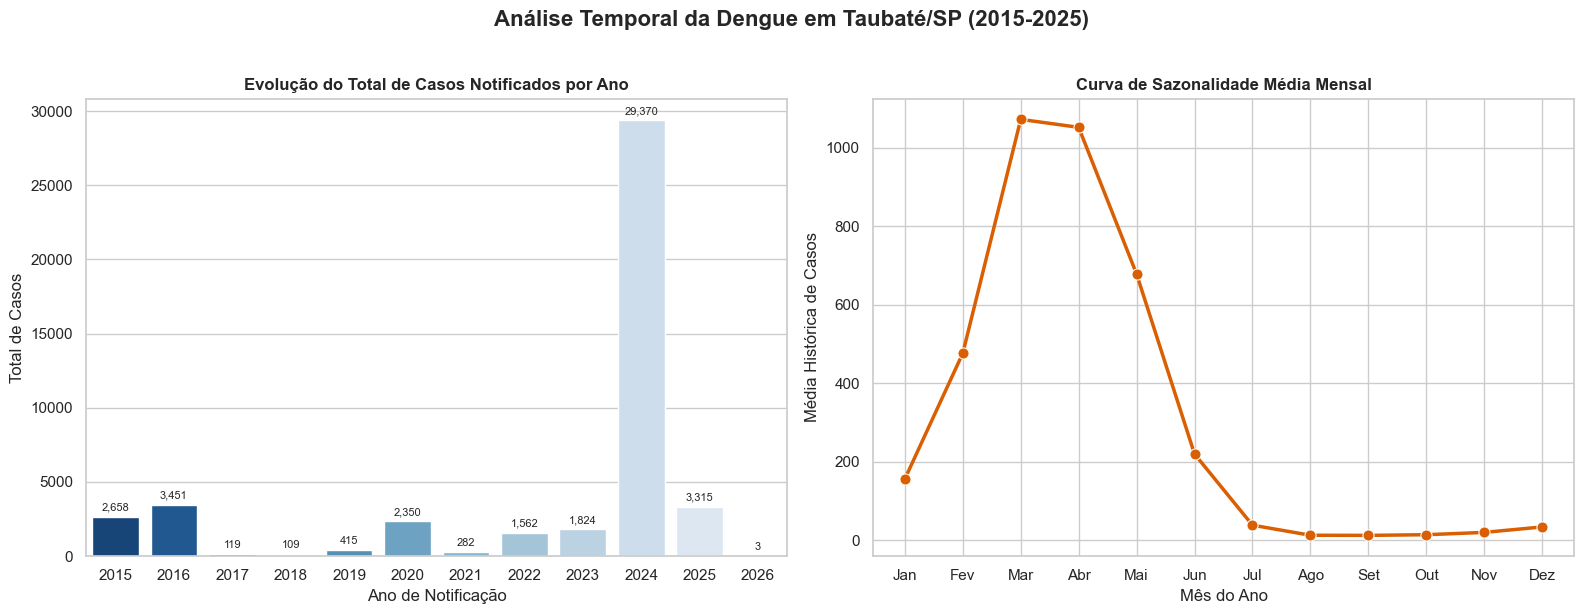

In [6]:
# ------------------------------------------------------------------------------
# 6. GERAÇÃO DE VISUAIS (FIGURA 1: VISÃO TEMPORAL E SAZONALIDADE)
# ------------------------------------------------------------------------------
print("\n📊 Gerando Figura 1: Visão Temporal e Sazonalidade...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise Temporal da Dengue em Taubaté/SP (2015-2025)', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1A: Evolução Anual
df_anual = df_sazonalidade.groupby('Ano')['Casos'].sum().reset_index()

ax1 = sns.barplot(
    data=df_anual, 
    x='Ano', 
    y='Casos', 
    hue='Ano', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Evolução do Total de Casos Notificados por Ano', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ano de Notificação')
axes[0].set_ylabel('Total de Casos')

for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height):,}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', fontsize=8, xytext=(0, 3), 
                     textcoords='offset points')

# Gráfico 1B: Sazonalidade Média Mensal
ordem_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
df_saz_mes = df_sazonalidade.copy()
df_saz_mes['Mes'] = pd.Categorical(df_saz_mes['Mes'], categories=ordem_meses, ordered=True)
df_mes_media = df_saz_mes.groupby('Mes', observed=True)['Casos'].mean().reset_index()

sns.lineplot(
    data=df_mes_media, 
    x='Mes', 
    y='Casos', 
    marker='o', 
    color='#d95f02', 
    linewidth=2.5, 
    markersize=8, 
    ax=axes[1]
)
axes[1].set_title('Curva de Sazonalidade Média Mensal', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mês do Ano')
axes[1].set_ylabel('Média Histórica de Casos')

plt.tight_layout()
plt.savefig(os.path.join(PASTA_IMAGENS, '01_sazonalidade_e_tendencia.png'), dpi=300, bbox_inches='tight')
plt.show()

📊 Gerando Figura 2: Perfil Demográfico e Severidade...


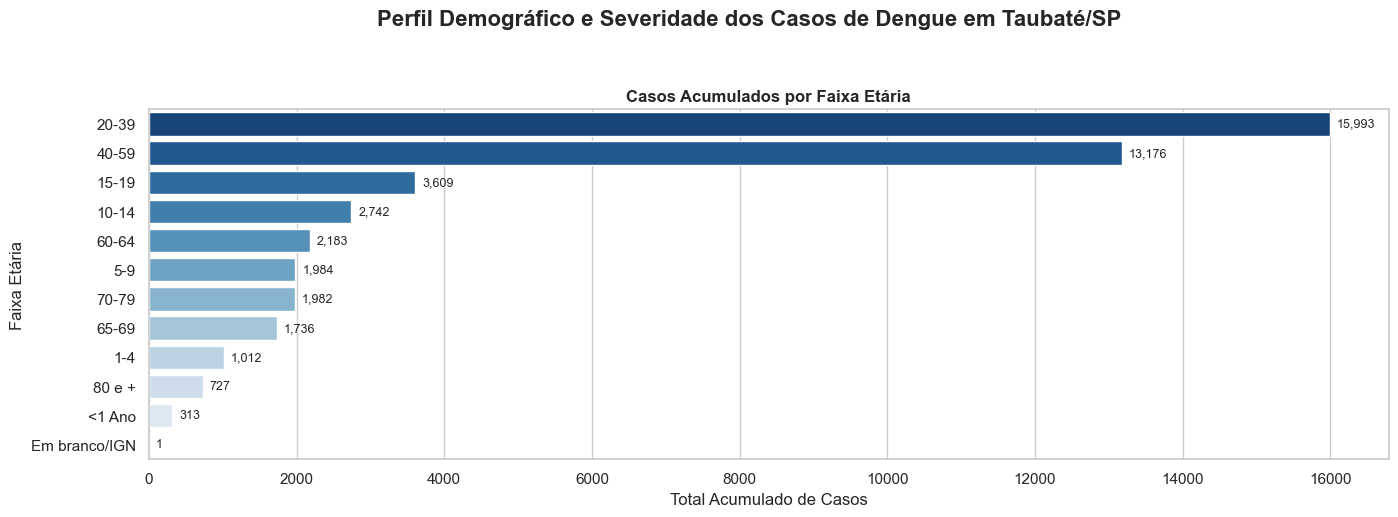

In [7]:
# ------------------------------------------------------------------------------
# 7. GERAÇÃO DE VISUAIS (FIGURA 2: DEMOGRAFIA E SEVERIDADE)
# ------------------------------------------------------------------------------
print("📊 Gerando Figura 2: Perfil Demográfico e Severidade...")

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Perfil Demográfico e Severidade dos Casos de Dengue em Taubaté/SP', fontsize=16, fontweight='bold', y=0.98)

# Gráfico 2A: Distribuição por Faixa Etária
ax_faixa = plt.subplot2grid((2, 2), (0, 0), colspan=2)
df_faixa_totais = df_faixa_etaria.groupby('Faixa_Etaria')['Casos'].sum().reset_index().sort_values(by='Casos', ascending=False)

sns.barplot(
    data=df_faixa_totais, 
    x='Casos', 
    y='Faixa_Etaria', 
    hue='Faixa_Etaria', 
    palette='Blues_r', 
    legend=False, 
    ax=ax_faixa
)
ax_faixa.set_title('Casos Acumulados por Faixa Etária', fontsize=12, fontweight='bold')
ax_faixa.set_xlabel('Total Acumulado de Casos')
ax_faixa.set_ylabel('Faixa Etária')

for p in ax_faixa.patches:
    width = p.get_width()
    if width > 0:
        ax_faixa.annotate(f'{int(width):,}', 
                          (width, p.get_y() + p.get_height() / 2.), 
                          ha='left', va='center', fontsize=9, xytext=(5, 0), 
                          textcoords='offset points')



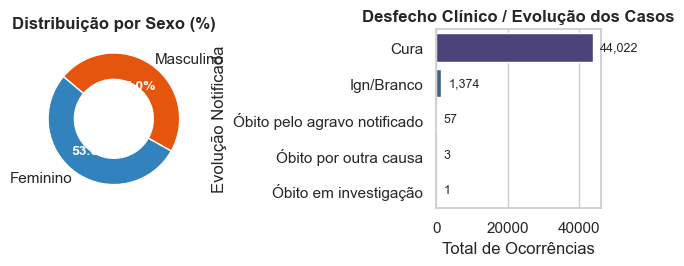


🚀 PROCESSO CONCLUÍDO COM SUCESSO!
1. Arquivos CSV limpos salvos em: 'Dados/Processados/'
2. Imagens dos gráficos salvas em: 'imagens/'


In [8]:
# Gráfico 2B: Proporção por Sexo (Donut Chart)
ax_sexo = plt.subplot2grid((2, 2), (1, 0))
df_sexo_total = df_sexo_evolucao.groupby('Sexo')['Casos'].sum().reset_index()

colors = ['#3182bd', '#e6550d']
wedges, texts, autotexts = ax_sexo.pie(
    df_sexo_total['Casos'], 
    labels=df_sexo_total['Sexo'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    wedgeprops=dict(width=0.4, edgecolor='w')
)
plt.setp(autotexts, size=10, weight="bold", color="white")
ax_sexo.set_title('Distribuição por Sexo (%)', fontsize=12, fontweight='bold')

# Gráfico 2C: Desfecho Clínico (Evolução)
ax_evol = plt.subplot2grid((2, 2), (1, 1))
df_evol_total = df_sexo_evolucao.groupby('Evolucao')['Casos'].sum().reset_index().sort_values(by='Casos', ascending=False)

sns.barplot(
    data=df_evol_total, 
    x='Casos', 
    y='Evolucao', 
    hue='Evolucao', 
    palette='viridis',  # Paleta 'viridis' em minúsculo
    legend=False, 
    ax=ax_evol
)
ax_evol.set_title('Desfecho Clínico / Evolução dos Casos', fontsize=12, fontweight='bold')
ax_evol.set_xlabel('Total de Ocorrências')
ax_evol.set_ylabel('Evolução Notificada')

for p in ax_evol.patches:
    width = p.get_width()
    if width > 0:
        ax_evol.annotate(f'{int(width):,}', 
                          (width, p.get_y() + p.get_height() / 2.), 
                          ha='left', va='center', fontsize=9, xytext=(5, 0), 
                          textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(PASTA_IMAGENS, '02_demografia_e_severidade.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n🚀 PROCESSO CONCLUÍDO COM SUCESSO!")
print("1. Arquivos CSV limpos salvos em: 'Dados/Processados/'")
print("2. Imagens dos gráficos salvas em: 'imagens/'")